# OI Terminal Volatility Audit

이 노트북은 **OI Terminal Volatility**를 실제 Binance BTCUSDT perpetual 데이터로 검증한다.

핵심 질문은 다음과 같다.

1. Price/OI Box가 끝나기 직전에 Open Interest 변동성이 평소보다 커지는가?
2. 이런 변화는 단순한 방향 예측 신호인가, 아니면 range 전략을 조심해야 하는 transition/risk signal인가?
3. Terminal OI risk-off 필터를 백테스트에 넣으면 거래 품질이 개선되는가?

이 노트북의 목표는 “가격이 크게 움직이기 전에 OI 구조가 먼저 불안정해지는지”를 수식, 시각화, 백테스트로 확인하는 것이다.

## 1. Concept: OI Terminal Volatility

OI Terminal Volatility는 박스 끝부분에서 OI의 움직임이 평소보다 커지는지 보는 지표다.

박스 내부를 두 구간으로 나눈다.

```text
OI Box
|-----------------------------------------------|
|                baseline             terminal  |
|         평소 박스 내부 움직임          끝부분   |
```

- `baseline`: 박스 안에서 평소 OI가 얼마나 안정적인지 측정하는 구간
- `terminal`: 박스가 끝나기 직전 OI가 갑자기 불안정해지는지 보는 구간

이 신호는 “매수/매도 방향을 바로 맞히는 신호”라기보다, **기존 range mean-reversion을 계속 해도 되는지 의심해야 하는 risk/transition signal**에 가깝다.

## 2. Formula

기준 구간의 robust range는 분위수로 계산한다.

$$
Range_{base}=Q_{90}(OI_{base})-Q_{10}(OI_{base})
$$

박스 끝 구간의 range도 같은 방식으로 계산한다.

$$
Range_{terminal}=Q_{90}(OI_{terminal})-Q_{10}(OI_{terminal})
$$

변동성 확대 비율은 다음과 같다.

$$
RangeRatio=
\frac{Range_{terminal}}
{\max(Range_{base}, RobustScale(OI_{base}))}
$$

한 방향 순변화는 baseline의 평소 변화 단위로 나눠 z-score처럼 본다.

$$
NetChangeZ=
\frac{|OI_{terminal,end}-OI_{terminal,start}|}
{RobustScale(\Delta OI_{base})}
$$

최종 신호 조건은 OR 조건이다.

$$
RangeRatio \geq \theta_{range}
\quad \text{or} \quad
NetChangeZ \geq \theta_z
$$

즉, terminal 구간에서 OI가 **크게 흔들리거나**, **한 방향으로 강하게 밀리면** terminal risk signal로 본다.

## 3. Setup

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'takora-trading' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path(os.environ.get('TAKORA_DATA_ROOT', '/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))
OUTPUT_DIR = PROJECT_ROOT / 'research/notebooks/_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from research.microstructure_alpha.oi_box import detect_oi_box_ranges
from research.microstructure_alpha.box_event_signals import detect_box_terminal_oi_volatility
from research.microstructure_alpha.box_strategy_backtest import (
    BoxStrategyConfig,
    build_box_strategy_frame,
    candidate_box_strategy_configs,
    optimize_box_strategy,
)

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT, DATA_ROOT

(PosixPath('/Users/changminkim/Desktop/projects/equidice/takora-trading'),
 PosixPath('/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))

## 4. Analysis Window

기본 구간은 포트폴리오 진단 구간과 맞춘다.

- 시작: `2026-05-22 00:00:00`
- 종료: `2026-07-18 23:55:00`
- 봉: `5min`

구간을 바꾸려면 아래 변수만 수정하면 된다.

In [ ]:
START_TIME = '2026-05-22 00:00:00'
END_TIME = '2026-07-18 23:55:00'
BAR_SIZE = '5m'

start_ts = pd.Timestamp(START_TIME)
end_ts = pd.Timestamp(END_TIME)
print(start_ts, '->', end_ts, BAR_SIZE)

2026-05-22 00:00:00 -> 2026-07-18 23:55:00 5m


분석 구간은 `2026-05-22 00:00:00`부터 `2026-07-18 23:55:00`까지이며, 5분봉 기준으로 계산한다. 이 구간은 포트폴리오에서 사용한 주요 진단 구간과 맞춰져 있어, 이전 Price/OI Box 전략 결과와 비교하기 쉽다.

## 5. Binance Price / OI Loader

사용 데이터:

- Binance BTCUSDT perpetual trades: 5분봉 OHLCV 생성
- Binance BTCUSDT perpetual open interest: 5분 단위 OI value 생성

OI는 가능하면 `sum_open_interest_value`를 사용하고, 값이 비어 있으면 `sum_open_interest × BTC close`로 USD 노출을 근사한다.

In [3]:
def date_filtered_paths(root: Path, pattern: str, start: pd.Timestamp, end: pd.Timestamp) -> list[Path]:
    paths = sorted(root.glob(pattern))
    dates = set(pd.date_range(start.normalize(), end.normalize(), freq='D').strftime('%Y-%m-%d'))
    selected = [path for path in paths if any(date in path.name for date in dates)]
    return selected if selected else paths


def parquet_timestamp_unit(path: Path, column: str) -> str:
    sample = pl.read_parquet(path, columns=[column], n_rows=1)
    value = int(sample[column][0])
    if value > 10**17:
        return 'ns'
    if value > 10**14:
        return 'us'
    if value > 10**11:
        return 'ms'
    return 's'


def load_binance_trades_ohlcv(
    *,
    data_root: Path = DATA_ROOT,
    start: str | pd.Timestamp = START_TIME,
    end: str | pd.Timestamp = END_TIME,
    bar_size: str = BAR_SIZE,
) -> pd.DataFrame:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    paths = date_filtered_paths(
        data_root,
        'binance/assets/btcusdt/future/trades/hour/*.parquet',
        start,
        end,
    )
    if not paths:
        raise FileNotFoundError('No Binance trades parquet files found')

    lf = (
        pl.scan_parquet([str(path) for path in paths])
        .with_columns([
            pl.from_epoch(pl.col('trade_time'), time_unit='ms').alias('timestamp'),
            pl.col('price').cast(pl.Float64, strict=False).alias('price'),
            pl.col('quantity').cast(pl.Float64, strict=False).alias('quantity'),
        ])
        .filter(pl.col('timestamp') >= start.to_pydatetime())
        .filter(pl.col('timestamp') <= end.to_pydatetime())
        .drop_nulls(['timestamp', 'price', 'quantity'])
        .filter((pl.col('price') > 0) & (pl.col('quantity') > 0))
        .sort('timestamp')
        .group_by_dynamic('timestamp', every=bar_size, period=bar_size)
        .agg([
            pl.col('price').first().alias('open'),
            pl.col('price').max().alias('high'),
            pl.col('price').min().alias('low'),
            pl.col('price').last().alias('close'),
            pl.col('quantity').sum().alias('volume'),
            pl.len().alias('trade_count'),
        ])
    )
    out = lf.collect().to_pandas()
    out['timestamp'] = pd.to_datetime(out['timestamp']).astype('datetime64[ns]')
    return out.dropna(subset=['open', 'high', 'low', 'close']).sort_values('timestamp').reset_index(drop=True)


def load_binance_open_interest(
    price_frame: pd.DataFrame,
    *,
    data_root: Path = DATA_ROOT,
    start: str | pd.Timestamp = START_TIME,
    end: str | pd.Timestamp = END_TIME,
    bar_size: str = BAR_SIZE,
) -> pd.DataFrame:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    paths = date_filtered_paths(
        data_root,
        'binance/assets/btcusdt/future/openinterest/hour/*.parquet',
        start,
        end,
    )
    if not paths:
        raise FileNotFoundError('No Binance openinterest parquet files found')

    unit = parquet_timestamp_unit(paths[0], 'timestamp')
    sample_columns = pl.read_parquet(paths[0], n_rows=1).columns
    has_value = 'sum_open_interest_value' in sample_columns

    value_expr = (
        pl.col('sum_open_interest_value').cast(pl.Float64, strict=False).alias('oi_value_raw')
        if has_value else
        pl.lit(None, dtype=pl.Float64).alias('oi_value_raw')
    )

    lf = (
        pl.scan_parquet([str(path) for path in paths])
        .with_columns([
            pl.from_epoch(pl.col('timestamp'), time_unit=unit).alias('timestamp_dt'),
            pl.col('sum_open_interest').cast(pl.Float64, strict=False).alias('oi_amount'),
            value_expr,
        ])
        .filter(pl.col('timestamp_dt') >= start.to_pydatetime())
        .filter(pl.col('timestamp_dt') <= end.to_pydatetime())
        .drop_nulls(['timestamp_dt', 'oi_amount'])
        .sort('timestamp_dt')
        .group_by_dynamic('timestamp_dt', every=bar_size, period=bar_size)
        .agg([
            pl.col('oi_amount').last().alias('oi_amount'),
            pl.col('oi_value_raw').last().alias('oi_value_raw'),
        ])
    )
    oi = lf.collect().to_pandas().rename(columns={'timestamp_dt': 'timestamp'})
    oi['timestamp'] = pd.to_datetime(oi['timestamp']).astype('datetime64[ns]')
    oi = oi.sort_values('timestamp').reset_index(drop=True)

    price_close = price_frame[['timestamp', 'close']].copy().sort_values('timestamp')
    oi = pd.merge_asof(oi, price_close, on='timestamp', direction='backward')
    oi['oi_value_usd'] = pd.to_numeric(oi['oi_value_raw'], errors='coerce')
    fallback_value = pd.to_numeric(oi['oi_amount'], errors='coerce') * pd.to_numeric(oi['close'], errors='coerce')
    oi['oi_value_usd'] = oi['oi_value_usd'].where(oi['oi_value_usd'].notna() & (oi['oi_value_usd'] > 0), fallback_value)
    oi = oi.dropna(subset=['oi_value_usd']).reset_index(drop=True)
    return oi[['timestamp', 'oi_amount', 'oi_value_raw', 'oi_value_usd']]

price_df = load_binance_trades_ohlcv()
oi_df = load_binance_open_interest(price_df)

common_start = max(price_df['timestamp'].min(), oi_df['timestamp'].min())
common_end = min(price_df['timestamp'].max(), oi_df['timestamp'].max())
price_df = price_df[(price_df['timestamp'] >= common_start) & (price_df['timestamp'] <= common_end)].reset_index(drop=True)
oi_df = oi_df[(oi_df['timestamp'] >= common_start) & (oi_df['timestamp'] <= common_end)].reset_index(drop=True)

print('price rows:', len(price_df), price_df['timestamp'].min(), '->', price_df['timestamp'].max())
print('oi rows:', len(oi_df), oi_df['timestamp'].min(), '->', oi_df['timestamp'].max())
display(price_df.head())
display(oi_df.head())

price rows: 16703 2026-05-22 00:00:00 -> 2026-07-18 23:50:00
oi rows: 16703 2026-05-22 00:00:00 -> 2026-07-18 23:50:00


,timestamp,open,high,low,close,volume,trade_count
0,2026-05-22 00:00:00,77586.3,77602.5,77480.0,77507.8,324.233,10270
1,2026-05-22 00:05:00,77507.9,77533.9,77497.5,77497.5,105.221,4533
2,2026-05-22 00:10:00,77497.5,77497.5,77405.4,77405.5,256.104,7238
3,2026-05-22 00:15:00,77405.4,77498.6,77374.4,77442.4,278.306,9473
4,2026-05-22 00:20:00,77442.3,77520.5,77441.2,77506.8,110.727,6209


,timestamp,oi_amount,oi_value_raw,oi_value_usd
0,2026-05-22 00:00:00,100697.616,7.812745e+09,7.812745e+09
1,2026-05-22 00:05:00,100753.997,7.809553e+09,7.809553e+09
2,2026-05-22 00:10:00,100756.618,7.808386e+09,7.808386e+09
3,2026-05-22 00:15:00,100781.085,7.801609e+09,7.801609e+09
4,2026-05-22 00:20:00,100789.294,7.805365e+09,7.805365e+09


가격 데이터와 OI 데이터가 모두 **16,703개 5분봉**으로 정렬되었다. 실제 마지막 timestamp는 `2026-07-18 23:50:00`인데, 이는 5분봉 집계 특성상 종료 시각 `23:55` 직전의 마지막 완성 bar가 `23:50`이기 때문이다.

첫 행의 trade count와 volume을 보면 Binance BTCUSDT perpetual 체결 데이터가 충분히 촘촘하게 들어와 있다. 또한 price/OI row 수가 동일하게 맞춰졌기 때문에 이후 `merge_asof`나 box overlay 과정에서 시간축 불일치로 인한 왜곡 가능성이 낮다.

## 6. Detect Price Box and OI Box

Terminal OI volatility는 OI Box의 끝부분에서 계산한다.

여기서는 다음 두 박스를 만든다.

- `price_boxes`: 가격 기준 박스
- `oi_boxes`: Binance OI value 기준 박스

Price Box와 OI Box를 각각 만든다. Price Box는 실제 진입 range의 기준이 되고, OI Box는 “현재 OI 구조가 안정적인 박스 상태인지”를 확인하는 필터 역할을 한다.

실행 결과에서 box 수가 충분히 나온다면, 이후 terminal volatility는 “아무 구간에서나 OI가 튄 것”이 아니라 **OI Box의 끝부분에서 변화가 커졌는지**를 평가하게 된다. 반대로 box 수가 너무 적으면 `min_bars`, `center_shift_bars`, `center_shift_ratio`가 현재 데이터 구간에 비해 지나치게 보수적인지 확인해야 한다.

In [ ]:
price_boxes = detect_oi_box_ranges(
    price_df,
    timestamp_col='timestamp',
    value_col='close',
    min_bars=72,
    center_shift_bars=48,
    center_shift_ratio=0.90,
    breakout_confirm_bars=6,
)

oi_boxes = detect_oi_box_ranges(
    oi_df,
    timestamp_col='timestamp',
    value_col='oi_value_usd',
    min_bars=72,
    center_shift_bars=48,
    center_shift_ratio=0.90,
    breakout_confirm_bars=6,
)

print('price boxes:', len(price_boxes))
print('oi boxes:', len(oi_boxes))

display(pd.DataFrame([box.__dict__ for box in price_boxes]).head(10))
display(pd.DataFrame([box.__dict__ for box in oi_boxes]).head(10))

## 7. Detect OI Terminal Volatility

각 OI Box의 마지막 구간에서 다음을 계산한다.

- `range_ratio`: 박스 끝 구간 OI 변동폭이 baseline 대비 얼마나 커졌는가?
- `net_change_z`: 박스 끝 구간 OI 순변화가 baseline 변화 단위 대비 얼마나 큰가?
- `is_terminal_oi_expansion`: 둘 중 하나라도 기준 이상이면 True

In [5]:
terminal_oi_volatility = detect_box_terminal_oi_volatility(
    oi_df,
    oi_boxes,
    timestamp_col='timestamp',
    value_col='oi_value_usd',
    lookback_bars=144,       # baseline 12h on 5m bars
    terminal_bars=36,        # terminal 3h
    min_range_ratio=1.8,
    min_net_change_z=3.0,
)

print('terminal rows:', len(terminal_oi_volatility))
print('signals:', int(terminal_oi_volatility.get('is_terminal_oi_expansion', pd.Series(dtype=bool)).sum()))
display_cols = [
    'box_id', 'box_start', 'box_end', 'terminal_start', 'terminal_end',
    'baseline_range', 'terminal_range', 'range_ratio',
    'terminal_net_change', 'net_change_z', 'path_ratio', 'direction',
    'is_terminal_oi_expansion',
]
display(terminal_oi_volatility[display_cols].sort_values(['is_terminal_oi_expansion', 'range_ratio', 'net_change_z'], ascending=[False, False, False]).head(20))

terminal rows: 31
signals: 22


,box_id,box_start,box_end,terminal_start,terminal_end,baseline_range,terminal_range,range_ratio,terminal_net_change,net_change_z,path_ratio,direction,is_terminal_oi_expansion
16,59,2026-06-24 13:25:00,2026-06-25 15:55:00,2026-06-25 13:00:00,2026-06-25 15:55:00,1.041036e+08,2.459424e+08,2.362477,1.853002e+08,29.351485,3.616604,up,True
17,62,2026-06-26 12:40:00,2026-06-28 17:10:00,2026-06-28 14:15:00,2026-06-28 17:10:00,3.102602e+07,6.297612e+07,2.029784,-6.555788e+07,16.244669,1.557706,down,True
18,65,2026-06-29 12:05:00,2026-06-30 13:40:00,2026-06-30 10:45:00,2026-06-30 13:40:00,6.102850e+07,1.048063e+08,1.717334,1.023615e+08,17.880696,2.227911,up,True
3,17,2026-05-29 16:55:00,2026-06-01 13:40:00,2026-06-01 10:45:00,2026-06-01 13:40:00,8.359564e+07,1.270101e+08,1.519339,-8.805715e+07,12.986078,1.911353,down,True
19,66,2026-06-30 13:45:00,2026-07-01 06:30:00,2026-07-01 03:35:00,2026-07-01 06:30:00,6.254479e+07,7.845196e+07,1.254332,-1.113644e+08,12.955301,0.761880,down,True
4,25,2026-06-04 00:30:00,2026-06-04 16:55:00,2026-06-04 14:00:00,2026-06-04 16:55:00,7.199348e+07,8.402248e+07,1.167085,-8.047579e+07,4.602031,0.643775,down,True
12,48,2026-06-17 15:50:00,2026-06-18 15:20:00,2026-06-18 12:25:00,2026-06-18 15:20:00,6.446305e+07,6.426678e+07,0.996955,-8.893738e+07,13.061924,2.189335,down,True
11,46,2026-06-16 14:30:00,2026-06-17 07:45:00,2026-06-17 04:50:00,2026-06-17 07:45:00,5.476351e+07,5.321065e+07,0.971644,-5.741524e+07,10.760775,1.132691,down,True
14,55,2026-06-21 20:35:00,2026-06-22 12:20:00,2026-06-22 09:25:00,2026-06-22 12:20:00,8.711761e+07,8.455582e+07,0.970594,8.716587e+07,11.826368,0.966821,up,True
25,87,2026-07-10 08:20:00,2026-07-11 14:20:00,2026-07-11 11:25:00,2026-07-11 14:20:00,1.725006e+07,1.639530e+07,0.950449,1.910679e+07,6.027749,0.716589,up,True


총 **31개 terminal 평가 row** 중 **22개가 terminal OI expansion signal**로 잡혔다. 약 **71.0%** 비율이므로, 이 구간에서는 OI Box 끝부분에서 평소와 다른 움직임이 꽤 자주 관찰된다.

상위 이벤트를 보면 `2026-06-25 13:00:00 ~ 15:55:00` 구간이 가장 강하다. 이 구간은 `RangeRatio=2.36`, `NetChangeZ=29.35`, 방향은 `up`으로 나타났다. 즉 단순히 OI가 조금 흔들린 정도가 아니라, terminal 구간에서 OI가 baseline 변화 단위 대비 매우 크게 한 방향으로 증가한 구간이다.

표 전체의 경향은 `RangeRatio`보다 `NetChangeZ` 쪽이 훨씬 강하다. 이는 “끝부분에서 OI의 위아래 변동폭이 넓어졌다”기보다, **"OI가 한 방향으로 누적되거나 이탈하는 순변화가 컸다"** 로 해석하였다.

## 7-1. Terminal OI Signal Output
- `terminal_signal_count`: terminal 구간에서 OI expansion 조건을 만족한 이벤트 수
- `terminal_signal_rate_pct`: 전체 terminal 평가 row 중 signal로 분류된 비율
- `range_only_count`: `range_ratio` 조건만 통과한 이벤트 수
- `net_change_z_only_count`: `net_change_z` 조건만 통과한 이벤트 수
- `both_condition_count`: 두 조건을 동시에 통과한 이벤트 수
- `avg_range_ratio_signal_only`: signal 이벤트만 대상으로 계산한 평균 range ratio
- `avg_net_change_z_signal_only`: signal 이벤트만 대상으로 계산한 평균 net change z-score
- `top_signal_events_by_net_change_z_and_range_ratio`: 신호 강도가 큰 terminal 이벤트 목록

In [21]:
def _fmt_num(value, digits=2):
    if pd.isna(value):
        return 'N/A'
    return f'{float(value):,.{digits}f}'


def print_terminal_oi_signal_output(
    events: pd.DataFrame,
    oi_boxes,
    *,
    range_threshold: float = 1.8,
    z_threshold: float = 3.0,
    top_n: int = 10,
) -> pd.DataFrame:
    total_boxes = len(oi_boxes)
    total_rows = len(events)

    print('Terminal OI Signal Output')
    print('-' * 32)
    print(f'oi_box_count: {total_boxes}')
    print(f'terminal_event_rows: {total_rows}')
    print(f'range_threshold: {range_threshold:.2f}')
    print(f'net_change_z_threshold: {z_threshold:.2f}')

    if events.empty:
        print('terminal_signal_count: 0')
        print('terminal_signal_rate_pct: 0.00')
        return pd.DataFrame()

    signal_mask = events['is_terminal_oi_expansion'].fillna(False)
    signaled = events[signal_mask].copy()
    signal_count = int(signal_mask.sum())
    signal_rate = signal_count / max(total_rows, 1) * 100

    range_hit = events['range_ratio'] >= range_threshold
    z_hit = events['net_change_z'] >= z_threshold

    summary = pd.DataFrame([
        {'metric': 'terminal_signal_count', 'value': signal_count},
        {'metric': 'terminal_signal_rate_pct', 'value': round(signal_rate, 2)},
        {'metric': 'range_only_count', 'value': int((range_hit & ~z_hit).sum())},
        {'metric': 'net_change_z_only_count', 'value': int((~range_hit & z_hit).sum())},
        {'metric': 'both_condition_count', 'value': int((range_hit & z_hit).sum())},
        {
            'metric': 'avg_range_ratio_signal_only',
            'value': _fmt_num(signaled['range_ratio'].mean()) if not signaled.empty else 'N/A',
        },
        {
            'metric': 'avg_net_change_z_signal_only',
            'value': _fmt_num(signaled['net_change_z'].mean()) if not signaled.empty else 'N/A',
        },
        {
            'metric': 'first_signal_time',
            'value': signaled['terminal_start'].min() if not signaled.empty else 'N/A',
        },
        {
            'metric': 'last_signal_time',
            'value': signaled['terminal_start'].max() if not signaled.empty else 'N/A',
        },
    ])

    print('\n[summary]')
    print(summary.to_string(index=False))

    event_columns = [
        'box_id',
        'terminal_start',
        'terminal_end',
        'range_ratio',
        'net_change_z',
        'direction',
        'is_terminal_oi_expansion',
    ]
    available_columns = [column for column in event_columns if column in signaled.columns]

    print(f'\n[top_signal_events_by_net_change_z_and_range_ratio: top_n={top_n}]')
    if signaled.empty:
        print('No signal events.')
    else:
        top_events = signaled.sort_values(
            ['net_change_z', 'range_ratio'],
            ascending=[False, False],
        ).head(top_n)
        print(top_events[available_columns].to_string(index=False))

    return summary


terminal_oi_signal_summary = print_terminal_oi_signal_output(terminal_oi_volatility, oi_boxes)


Terminal OI Signal Output
--------------------------------
oi_box_count: 100
terminal_event_rows: 31
range_threshold: 1.80
net_change_z_threshold: 3.00

[summary]
                      metric               value
       terminal_signal_count                  22
    terminal_signal_rate_pct               70.97
            range_only_count                   0
     net_change_z_only_count                  20
        both_condition_count                   2
 avg_range_ratio_signal_only                0.94
avg_net_change_z_signal_only               11.12
           first_signal_time 2026-05-23 04:50:00
            last_signal_time 2026-07-18 09:05:00

[top_signal_events_by_net_change_z_and_range_ratio: top_n=10]
 box_id      terminal_start        terminal_end  range_ratio  net_change_z direction  is_terminal_oi_expansion
     59 2026-06-25 13:00:00 2026-06-25 15:55:00     2.362477     29.351485        up                      True
     91 2026-07-13 10:20:00 2026-07-13 13:15:00     0.523153  

## 8. Visualization: OI Box End Expansion

아래 차트는 OI Box와 terminal risk signal을 함께 보여준다.

- 회색 음영: OI Box
- 주황 음영: terminal 구간
- 빨간 음영: terminal OI expansion signal
- 파란 선: Binance OI value

이 그림에서 보고 싶은 것은 “박스 끝부분에서 OI의 흔들림 폭이나 순변화가 평소와 달라졌는가?”다.

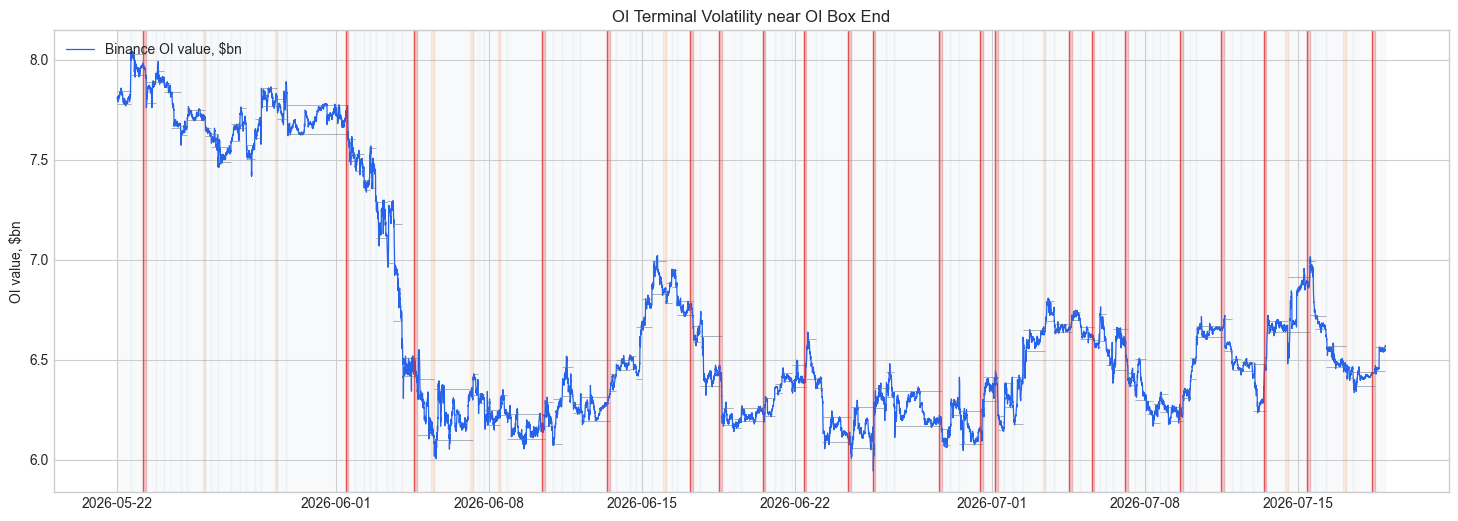

In [22]:
def plot_terminal_oi_volatility(
    oi_frame: pd.DataFrame,
    terminal_frame: pd.DataFrame,
    oi_boxes,
    *,
    value_col: str = 'oi_value_usd',
    max_signals: int | None = None,
):
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(oi_frame['timestamp'], oi_frame[value_col] / 1e9, color='#2563EB', linewidth=0.9, label='Binance OI value, $bn')

    for box in oi_boxes:
        ax.axvspan(box.start, box.end, color='#CBD5E1', alpha=0.12)
        ax.hlines([box.low / 1e9, box.high / 1e9], box.start, box.end, color='#64748B', linewidth=0.7, alpha=0.55)

    events = terminal_frame.copy()
    if max_signals is not None:
        events = events.head(max_signals)
    for row in events.itertuples(index=False):
        color = '#DC2626' if row.is_terminal_oi_expansion else '#F97316'
        alpha = 0.20 if row.is_terminal_oi_expansion else 0.10
        ax.axvspan(row.terminal_start, row.terminal_end, color=color, alpha=alpha)
        if row.is_terminal_oi_expansion:
            ax.axvline(row.terminal_start, color='#DC2626', linewidth=1.0, alpha=0.70)

    ax.set_title('OI Terminal Volatility near OI Box End')
    ax.set_ylabel('OI value, $bn')
    ax.legend(loc='upper left')
    return fig, ax

fig, ax = plot_terminal_oi_volatility(oi_df, terminal_oi_volatility, oi_boxes)
plt.show()

이 그래프는 OI value 위에 OI Box와 terminal 구간을 겹쳐 보여준다. 회색 박스 안에서 OI가 비교적 안정적으로 움직이다가, 일부 박스의 끝부분에서 붉은 terminal 구간이 표시된다.

붉은 구간은 “가격이 이미 크게 움직였다”는 뜻이 아니라, **OI Box의 마지막 부분에서 OI 구조가 평소와 달라졌다는 뜻**이다. 따라서 이 그래프의 핵심은 가격 예측보다 “기존 박스 상태가 더 이상 안정적이지 않을 수 있다”는 조기 경고를 확인하는 데 있다.

## 9. Visualization: RangeRatio and NetChangeZ

신호가 발생한 이유를 두 축으로 확인한다.

- `RangeRatio`가 높으면 terminal 구간의 OI 흔들림 폭이 커진 것이다.
- `NetChangeZ`가 높으면 terminal 구간에서 OI가 한 방향으로 크게 이동한 것이다.

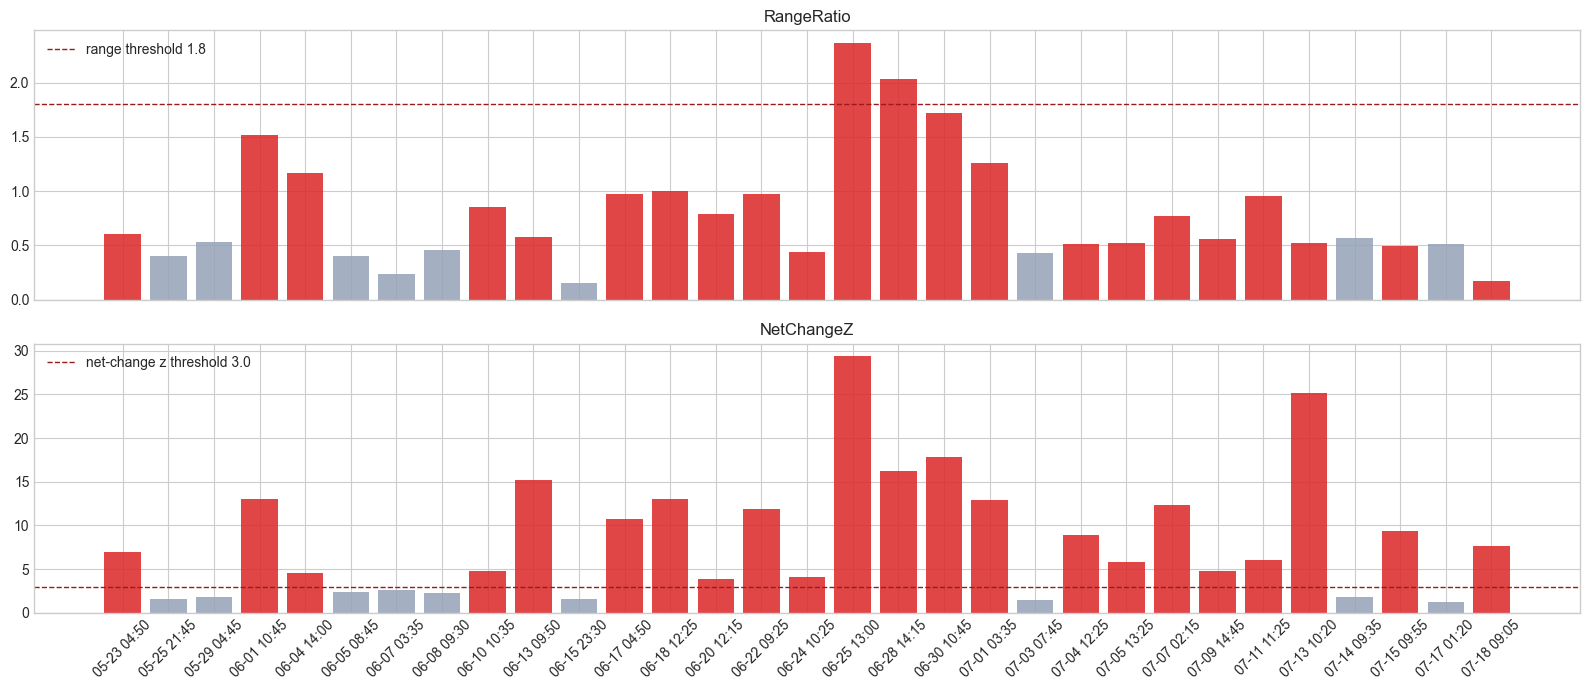

In [23]:
if terminal_oi_volatility.empty:
    print('No terminal volatility rows detected. Try longer analysis window or smaller min_bars.')
else:
    plot_df = terminal_oi_volatility.copy()
    plot_df['label'] = plot_df['terminal_start'].dt.strftime('%m-%d %H:%M')
    colors = np.where(plot_df['is_terminal_oi_expansion'], '#DC2626', '#94A3B8')

    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)
    axes[0].bar(plot_df['label'], plot_df['range_ratio'], color=colors, alpha=0.85)
    axes[0].axhline(1.8, color='#991B1B', linestyle='--', linewidth=1, label='range threshold 1.8')
    axes[0].set_title('RangeRatio')
    axes[0].legend(loc='upper left')

    axes[1].bar(plot_df['label'], plot_df['net_change_z'], color=colors, alpha=0.85)
    axes[1].axhline(3.0, color='#991B1B', linestyle='--', linewidth=1, label='net-change z threshold 3.0')
    axes[1].set_title('NetChangeZ')
    axes[1].legend(loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

막대 그래프를 보면 `RangeRatio`보다 `NetChangeZ`가 threshold를 넘는 경우가 훨씬 많다. 실제 출력에서도 `NetChangeZ` 단독 신호가 20개였고, `RangeRatio` 단독 신호는 없었다.

이는 이번 구간의 terminal OI 변화가 “넓게 흔들리는 변동성 확대”보다는 **한 방향으로 OI가 밀리는 구조 변화**에 가깝다는 뜻이다. 따라서 이후 전략에서는 이 신호를 단순 노이즈로 보기보다, 포지션 누적 또는 청산 이후 재진입 같은 구조 변화 가능성으로 해석할 수 있다.

## 10. Price Context: Did OI Move Before Price?

OI terminal signal이 가격 변화보다 먼저 나오는지 확인하기 위해 가격 차트와 함께 표시한다.

- 빨간 음영: terminal OI expansion signal
- 회색 음영: Price Box
- 검정 선: BTCUSDT close

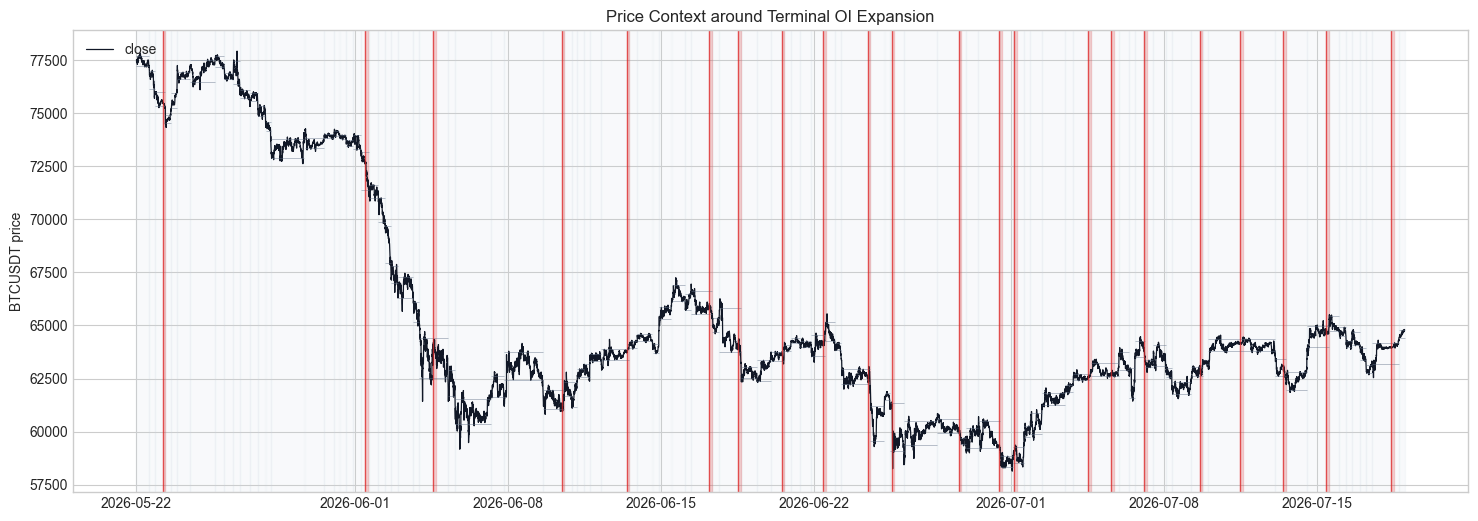

In [24]:
def plot_price_with_terminal_risk(price_frame, price_boxes, terminal_frame):
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(price_frame['timestamp'], price_frame['close'], color='#111827', linewidth=0.9, label='close')

    for box in price_boxes:
        ax.axvspan(box.start, box.end, color='#CBD5E1', alpha=0.12)
        ax.hlines([box.low, box.high], box.start, box.end, color='#64748B', linewidth=0.7, alpha=0.45)

    signals = terminal_frame[terminal_frame['is_terminal_oi_expansion'] == True]
    for row in signals.itertuples(index=False):
        ax.axvspan(row.terminal_start, row.terminal_end, color='#DC2626', alpha=0.18)
        ax.axvline(row.terminal_start, color='#DC2626', linewidth=1.0, alpha=0.75)

    ax.set_title('Price Context around Terminal OI Expansion')
    ax.set_ylabel('BTCUSDT price')
    ax.legend(loc='upper left')
    return fig, ax

fig, ax = plot_price_with_terminal_risk(price_df, price_boxes, terminal_oi_volatility)
plt.show()

가격 차트 위에 terminal OI signal을 겹치면, 가격이 아직 박스 내부에 있거나 박스 근처에 있을 때 OI 쪽에서 먼저 위험 신호가 발생하는 구간을 확인할 수 있다.

이 그림에서 중요한 포인트는 “빨간 구간 이후 가격이 항상 특정 방향으로 간다”가 아니다. 핵심은 **가격만 보고는 range 전략을 계속해도 될 것처럼 보이는 구간에서, OI는 이미 내부 구조 변화를 보여줄 수 있다**는 점이다. 그래서 이 신호는 진입 강화보다 range 진입 회피/축소에 더 적합하다.

## 11. Backtest

Terminal OI Volatility는 전략에서 다음 방식으로 사용한다.

- terminal risk signal이 없으면 기존 Price/OI Box range mean-reversion 전략을 그대로 수행한다.
- terminal risk signal이 있으면 `risk_off=True`가 되어 range 진입을 막거나 기존 range 포지션을 정리한다.

비교 시나리오:

1. `without_terminal_filter`: terminal OI risk를 사용하지 않음
2. `with_terminal_filter`: terminal OI risk를 사용함

두 시나리오는 같은 price box, OI box, 거래비용, 손절, 포지션 사이징 조건을 사용한다.

In [25]:
base_config = BoxStrategyConfig(
    entry_edge_ratio=0.08,
    bounce_confirm_bps=3.0,
    trailing_stop_bps=220.0,
    range_stop_buffer_bps=60.0,
    risk_per_trade=0.0015,
    max_leverage=0.70,
    max_holding_bars=288,
    require_oi_box_for_range=True,
    allow_short=True,
    fee_bps=4.0,
    slippage_bps=2.0,
    spread_bps=1.0,
)

candidate_configs = candidate_box_strategy_configs(
    base_config,
    entry_edge_ratios=(0.06, 0.08, 0.12, 0.18),
    bounce_confirm_bps_values=(0.0, 3.0, 8.0),
    trailing_stop_bps_values=(160.0, 220.0),
    range_stop_buffer_bps_values=(60.0, 110.0),
    risk_per_trade_values=(0.0015,),
)
print('candidate configs:', len(candidate_configs))

candidate configs: 48


후보 파라미터는 총 **48개**다. 조합 수가 너무 많지 않기 때문에, 과도한 최적화보다는 핵심 민감도만 비교하는 구조다.

조합 축은 `entry_edge_ratio`, `bounce_confirm_bps`, `trailing_stop_bps`, `range_stop_buffer_bps`로 구성되어 있다. 즉 “박스의 어느 위치에서 진입할지”, “짧은 반등/저항 확인을 얼마나 요구할지”, “손절과 trailing 조건을 어떻게 둘지”를 비교한다.

In [26]:
def build_terminal_strategy_frame(use_terminal_filter: bool, config: BoxStrategyConfig) -> pd.DataFrame:
    return build_box_strategy_frame(
        price_frame=price_df,
        oi_frame=oi_df,
        price_boxes=price_boxes,
        oi_boxes=oi_boxes,
        terminal_oi_volatility=terminal_oi_volatility if use_terminal_filter else pd.DataFrame(),
        transient_oi_shocks=pd.DataFrame(),
        deadcat_bounce_ranges=pd.DataFrame(),
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        oi_col='oi_value_usd',
        config=config,
    )


def run_terminal_scenario(name: str, use_terminal_filter: bool):
    frame = build_terminal_strategy_frame(use_terminal_filter, base_config)
    result, report = optimize_box_strategy(
        frame,
        candidate_configs=candidate_configs,
        timestamp_col='timestamp',
        price_col='close',
        high_col='high',
        low_col='low',
        min_win_rate=0.50,
        min_total_return=0.0,
        min_trades=5,
    )
    row = {
        'scenario': name,
        'uses_terminal_filter': use_terminal_filter,
        'passes_constraints': result.passes_constraints,
        'total_return_pct': result.metrics.get('total_return', np.nan) * 100,
        'win_rate_pct': result.metrics.get('win_rate', np.nan) * 100,
        'profit_factor': result.metrics.get('profit_factor', np.nan),
        'max_drawdown_pct': result.metrics.get('max_drawdown', np.nan) * 100,
        'total_trades': result.metrics.get('total_trades', np.nan),
    }
    return row, result, report

scenario_rows = []
scenario_results = {}
scenario_reports = {}

for name, use_filter in [
    ('without_terminal_filter', False),
    ('with_terminal_filter', True),
]:
    row, result, report = run_terminal_scenario(name, use_filter)
    scenario_rows.append(row)
    scenario_results[name] = result
    scenario_reports[name] = report

result_summary = pd.DataFrame(scenario_rows)
result_summary

,scenario,uses_terminal_filter,passes_constraints,total_return_pct,win_rate_pct,profit_factor,max_drawdown_pct,total_trades
0,without_terminal_filter,False,True,14.564312,74.703557,2.623193,-0.751391,253.0
1,with_terminal_filter,True,True,14.064598,76.033058,2.807306,-0.559764,242.0


In [29]:
def _scenario_row(summary: pd.DataFrame, scenario: str) -> pd.Series:
    rows = summary[summary['scenario'] == scenario]
    if rows.empty:
        raise ValueError(f'Missing scenario in result_summary: {scenario}')
    return rows.iloc[0]


def build_backtest_ablation_table(summary: pd.DataFrame) -> pd.DataFrame:
    base = _scenario_row(summary, 'without_terminal_filter')
    filt = _scenario_row(summary, 'with_terminal_filter')

    metric_specs = [
        ('Total Return', 'total_return_pct', '%'),
        ('Win Rate', 'win_rate_pct', '%'),
        ('Profit Factor', 'profit_factor', ''),
        ('Max Drawdown', 'max_drawdown_pct', '%'),
        ('Trades', 'total_trades', 'count'),
    ]

    rows = []
    for label, column, unit in metric_specs:
        without_value = float(base[column])
        with_value = float(filt[column])
        delta = with_value - without_value
        rows.append({
            'metric': label,
            'without_terminal_filter': round(without_value, 4),
            'with_terminal_filter': round(with_value, 4),
            'delta': round(delta, 4),
            'unit': unit,
        })

    return pd.DataFrame(rows)


backtest_ablation_table = build_backtest_ablation_table(result_summary)
backtest_ablation_table


,metric,without_terminal_filter,with_terminal_filter,delta,unit
0,Total Return,14.5643,14.0646,-0.4997,%
1,Win Rate,74.7036,76.0331,1.3295,%
2,Profit Factor,2.6232,2.8073,0.1841,
3,Max Drawdown,-0.7514,-0.5598,0.1916,%
4,Trades,253.0000,242.0000,-11.0000,count



| Metric | Without Terminal Filter | With Terminal Filter | Delta |
|---|---:|---:|---:|
| Total Return | 14.56% | 14.06% | -0.50%p |
| Win Rate | 74.70% | 76.03% | +1.33%p |
| Profit Factor | 2.62 | 2.81 | +0.19 |
| Max Drawdown | -0.75% | -0.56% | +0.19%p |
| Trades | 253 | 242 | -11 |


Terminal filter를 적용하면 총수익률은 소폭 낮아지지만(약 0.50%p 낮아졌지만), 승률(**+1.33%p**)과 Profit Factor(**+0.18**)가 개선되고 Max Drawdown(**약 0.19%p 개선**)은 덜 깊어진다. 거래 수가 줄어든 점까지 같이 보면, 이 필터는 공격적인 alpha signal이라기보다 저품질 range 진입을 일부 제거하는 risk filter에 가깝다.

따라서 해당 전략은 수익을 더 크게 만드는 알파 시그널은 아닐지라도, **거래 수를 조금 줄이면서 손실 품질과 안정성을 개선하는 risk filter**로 작용했다고 볼 수 있다.


## 12. Backtest Result Visualization

결과 해석의 핵심은 다음이다.

- Terminal filter가 수익률을 무조건 높이는지보다, 저품질 진입을 줄이고 MDD/PF/승률을 개선하는지 본다.
- 만약 수익률은 줄지만 MDD나 PF가 개선된다면, 이 신호는 alpha signal보다 risk filter에 가깝다.
- 만약 모든 지표가 악화된다면, threshold 또는 terminal window 정의를 다시 봐야 한다.

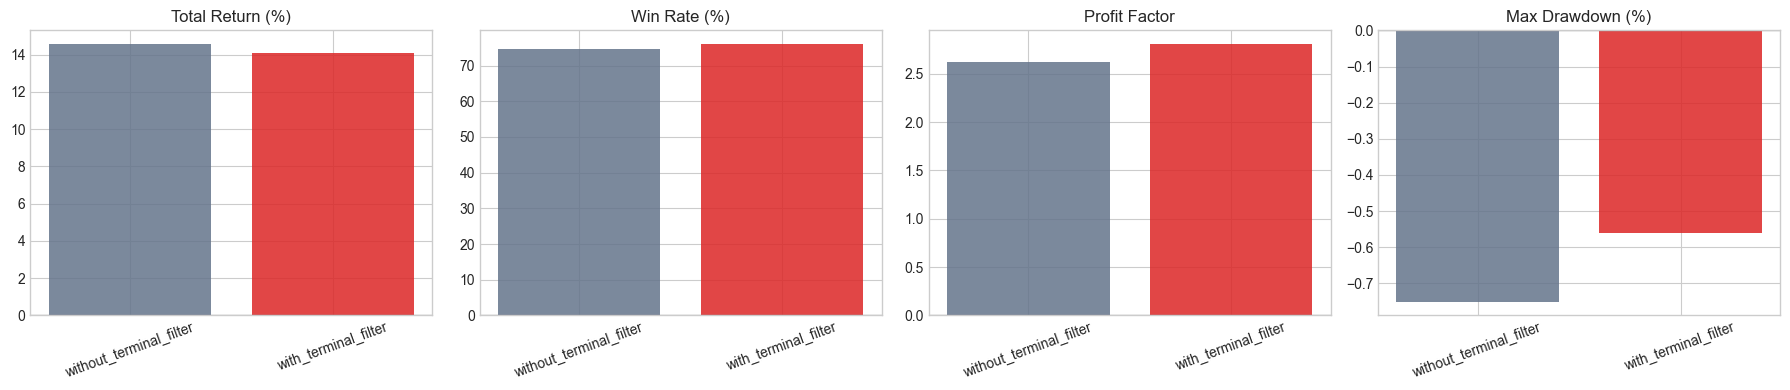

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
metrics_to_plot = [
    ('total_return_pct', 'Total Return (%)'),
    ('win_rate_pct', 'Win Rate (%)'),
    ('profit_factor', 'Profit Factor'),
    ('max_drawdown_pct', 'Max Drawdown (%)'),
]
colors = ['#64748B' if s == 'without_terminal_filter' else '#DC2626' for s in result_summary['scenario']]

for ax, (col, title) in zip(axes, metrics_to_plot):
    ax.bar(result_summary['scenario'], result_summary[col], color=colors, alpha=0.85)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='#111827', linewidth=0.8)

plt.tight_layout()
plt.show()

막대 그래프는 terminal filter 적용 전후의 핵심 지표를 한눈에 비교한다. 시각적으로는 `with_terminal_filter`가 Total Return에서는 약간 낮지만, Win Rate와 Profit Factor에서는 더 높고 Max Drawdown은 덜 깊다.

즉 이 필터는 “더 많은 수익 기회를 잡는 장치”라기보다, **일부 위험 구간을 제거해 거래 품질을 높이는 장치**로 보는 것이 맞다. 포트폴리오 설명에서는 이 점이 오히려 강점이다. 무조건 수익률만 높이는 것이 아니라, 신호의 역할을 risk management 관점에서 해석했기 때문이다.

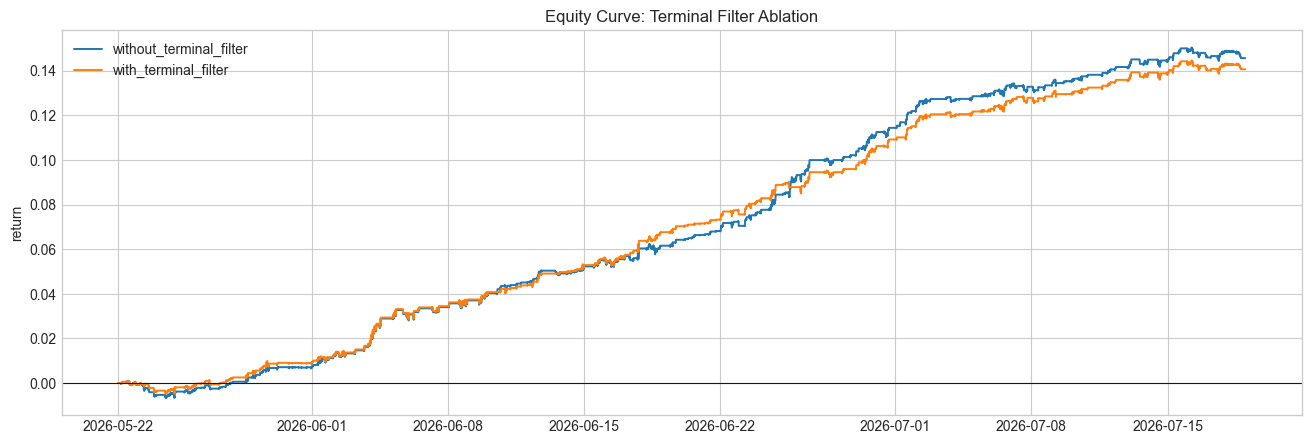

In [12]:
fig, ax = plt.subplots(figsize=(16, 5))
for name, result in scenario_results.items():
    curve = result.equity_curve.copy()
    if curve.empty:
        continue
    initial = curve['equity'].iloc[0]
    ax.plot(curve['timestamp'], curve['equity'] / initial - 1.0, label=name, linewidth=1.4)
ax.axhline(0, color='#111827', linewidth=0.8)
ax.set_title('Equity Curve: Terminal Filter Ablation')
ax.set_ylabel('return')
ax.legend()
plt.show()

Equity Curve에서는 두 시나리오가 모두 우상향하지만, terminal filter 적용 버전은 최종 수익률이 약간 낮은 대신 낙폭이 더 완만한 흐름을 보인다.

이 패턴은 risk filter에서 자주 나타난다. 위험 구간을 제거하면 일부 수익 거래도 함께 제거될 수 있지만, 손실 구간도 줄어들어 곡선이 조금 더 안정적으로 변한다. 따라서 이 그래프는 terminal OI filter가 “성과 극대화”보다 “성과 안정화”에 가까운 역할을 했다는 해석을 뒷받침한다.

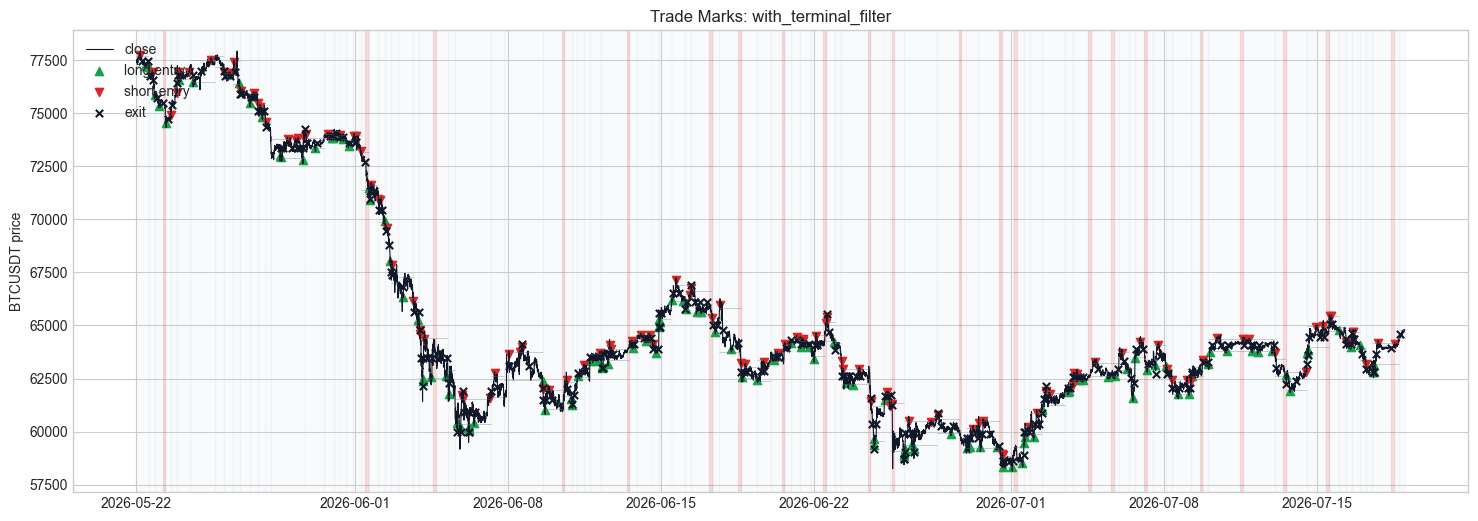

In [13]:
def plot_trade_marks_with_terminal(result, title: str):
    trades = result.trades.copy()
    fig, ax = plt.subplots(figsize=(18, 6))
    ax.plot(price_df['timestamp'], price_df['close'], color='#111827', linewidth=0.8, label='close')

    for box in price_boxes:
        ax.axvspan(box.start, box.end, color='#CBD5E1', alpha=0.10)
        ax.hlines([box.low, box.high], box.start, box.end, color='#64748B', linewidth=0.6, alpha=0.40)

    signals = terminal_oi_volatility[terminal_oi_volatility['is_terminal_oi_expansion'] == True]
    for row in signals.itertuples(index=False):
        ax.axvspan(row.terminal_start, row.terminal_end, color='#DC2626', alpha=0.12)

    if not trades.empty:
        long_entries = trades[trades['direction'] > 0]
        short_entries = trades[trades['direction'] < 0]
        ax.scatter(long_entries['entry_time'], long_entries['entry_price'], marker='^', s=35, color='#16A34A', label='long entry')
        ax.scatter(short_entries['entry_time'], short_entries['entry_price'], marker='v', s=35, color='#DC2626', label='short entry')
        ax.scatter(trades['exit_time'], trades['exit_price'], marker='x', s=28, color='#111827', label='exit')

    ax.set_title(title)
    ax.set_ylabel('BTCUSDT price')
    ax.legend(loc='upper left')
    return fig, ax

selected_name = 'with_terminal_filter' if 'with_terminal_filter' in scenario_results else next(iter(scenario_results))
fig, ax = plot_trade_marks_with_terminal(scenario_results[selected_name], f'Trade Marks: {selected_name}')
plt.show()

이 차트는 가격 박스, terminal OI risk 구간, 실제 진입/청산 위치를 함께 보여준다. terminal filter 적용 시에는 빨간 위험 구간에서 range 진입이 줄어드는지 확인하는 것이 핵심이다.

특히 진입 마커가 박스 상단/하단 근처에 몰려 있는지, 그리고 terminal risk 구간과 겹치는 진입이 줄었는지를 보면 필터가 실제로 전략 행동을 바꿨는지 확인할 수 있다.

## 13. Top Configs

각 시나리오에서 optimizer가 선택한 상위 후보를 확인한다.

이 표는 terminal filter가 단순히 성과 숫자만 바꾸는지, 아니면 어떤 진입 민감도/손절폭 조합에서 살아남는지 확인하기 위한 것이다.

In [14]:
for name, report in scenario_reports.items():
    print('\n===', name, 'top configs ===')
    display_cols = [
        'passes_constraints', 'entry_edge_ratio', 'bounce_confirm_bps', 'trailing_stop_bps',
        'range_stop_buffer_bps', 'risk_per_trade', 'total_return', 'win_rate',
        'profit_factor', 'max_drawdown', 'total_trades',
    ]
    available = [col for col in display_cols if col in report.columns]
    display(report[available].head(10))


=== without_terminal_filter top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,True,0.08,3.0,160.0,60.0,0.0015,0.145643,0.747036,2.623193,-0.007514,253.0
1,True,0.08,3.0,220.0,60.0,0.0015,0.145643,0.747036,2.623193,-0.007514,253.0
2,True,0.08,8.0,160.0,60.0,0.0015,0.140559,0.753623,2.953496,-0.004545,207.0
3,True,0.08,8.0,220.0,60.0,0.0015,0.140559,0.753623,2.953496,-0.004545,207.0
4,True,0.08,0.0,160.0,60.0,0.0015,0.140301,0.739583,2.309532,-0.007427,288.0
5,True,0.08,0.0,220.0,60.0,0.0015,0.140301,0.739583,2.309532,-0.007427,288.0
6,True,0.12,8.0,160.0,60.0,0.0015,0.135536,0.756198,2.605512,-0.006948,242.0
7,True,0.12,8.0,220.0,60.0,0.0015,0.135536,0.756198,2.605512,-0.006948,242.0
8,True,0.12,3.0,160.0,60.0,0.0015,0.133858,0.746667,2.267433,-0.007568,300.0
9,True,0.12,3.0,220.0,60.0,0.0015,0.133858,0.746667,2.267433,-0.007568,300.0



=== with_terminal_filter top configs ===


,passes_constraints,entry_edge_ratio,bounce_confirm_bps,trailing_stop_bps,range_stop_buffer_bps,risk_per_trade,total_return,win_rate,profit_factor,max_drawdown,total_trades
0,True,0.08,3.0,160.0,60.0,0.0015,0.140646,0.760331,2.807306,-0.005598,242.0
1,True,0.08,3.0,220.0,60.0,0.0015,0.140646,0.760331,2.807306,-0.005598,242.0
2,True,0.08,0.0,160.0,60.0,0.0015,0.137226,0.750903,2.447425,-0.005962,277.0
3,True,0.08,0.0,220.0,60.0,0.0015,0.137226,0.750903,2.447425,-0.005962,277.0
4,True,0.12,3.0,160.0,60.0,0.0015,0.134644,0.758621,2.430423,-0.005738,290.0
5,True,0.12,3.0,220.0,60.0,0.0015,0.134644,0.758621,2.430423,-0.005738,290.0
6,True,0.08,8.0,160.0,60.0,0.0015,0.131130,0.755102,3.067308,-0.004797,196.0
7,True,0.08,8.0,220.0,60.0,0.0015,0.131130,0.755102,3.067308,-0.004797,196.0
8,True,0.06,0.0,160.0,60.0,0.0015,0.130408,0.740741,2.510488,-0.006007,243.0
9,True,0.06,0.0,220.0,60.0,0.0015,0.130408,0.740741,2.510488,-0.006007,243.0


상위 파라미터를 보면 두 시나리오 모두 `entry_edge_ratio=0.08`, `bounce_confirm_bps=3.0`, `range_stop_buffer_bps=60.0`, `risk_per_trade=0.0015` 조합이 가장 높은 Total Return을 보인다. 즉 terminal filter를 넣어도 최적 파라미터의 큰 구조는 유지된다.

차이는 품질 지표에서 나타난다. 필터 미적용 최고 조합은 TR **14.56%**, 승률 **74.70%**, PF **2.62**, MDD **-0.75%**, 거래 수 **253회**다. 필터 적용 최고 조합은 TR **14.06%**, 승률 **76.03%**, PF **2.81**, MDD **-0.56%**, 거래 수 **242회**다.

또한 필터 적용 시 `bounce_confirm_bps=8.0` 조합은 TR은 낮아지지만 PF가 **3.07**까지 올라가고 MDD도 **-0.48%** 수준으로 개선된다. 이는 더 엄격한 반등 확인과 terminal risk filter를 결합하면 수익률은 줄어도 거래 품질은 더 좋아질 수 있음을 보여준다.

이 셀은 결과 재사용을 위해 summary, event, trade 파일을 저장한다. 포트폴리오 표를 다시 만들거나 다른 노트북에서 결과를 비교할 때 동일한 백테스트를 매번 재실행하지 않고 CSV를 불러와 사용할 수 있다.

저장되는 핵심 파일은 `oi_terminal_volatility_backtest_summary.csv`와 `oi_terminal_volatility_events.csv`다. 첫 번째는 성과 비교표, 두 번째는 terminal OI signal 자체의 이벤트 로그다.

## 15. Interpretation

OI Terminal Volatility의 의미는 다음처럼 정리할 수 있다.

1. 가격 박스가 아직 유지되는 것처럼 보여도, OI가 먼저 불안정해질 수 있다.
2. 이 변화는 신규 포지션 누적, 청산 압력, 포지션 교체 등으로 인해 발생할 수 있다.
3. 따라서 이 신호는 방향 예측용 entry signal보다는 range 전략의 risk-off/transition filter로 해석하는 편이 자연스럽다.
4. 백테스트에서는 terminal filter를 넣었을 때 승률, PF, MDD, 거래 수가 어떻게 변하는지를 함께 봐야 한다.

결론적으로, OI Terminal Volatility는 “수익을 바로 만드는 신호”라기보다 **거래하면 안 되는 구간을 줄이는 필터**로 검증하는 것이 더 적합하다.